# 🎬 Movie Recommendation System — BERT Similarity Analysis
### Data Mining Project — Task 2: BERT-based Analysis

**Goal:** Use BERT sentence embeddings to measure semantic similarity between movies based on their descriptions/overviews, and build a content-based recommender.

---
**Dataset required:** TMDB Movies Dataset  
📥 Download from Kaggle: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata  
→ Upload the file `tmdb_5000_movies.csv` and set the path in **Cell 2**


## 📦 Step 1 — Install Required Libraries

In [1]:
# Run this cell once — restart runtime after installation if needed
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn -q


## ⚙️ Step 2 — Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import kagglehub
# ─────────────────────────────────────────────────────────────────────────────
# 🔧 CONFIGURATION — Change paths here only
# ─────────────────────────────────────────────────────────────────────────────
CSV_PATH = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
paths = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

NUM_MOVIES  = 500                       # ← number of movies to process (start small for speed)
MODEL_NAME  = "all-MiniLM-L6-v2"       # ← BERT model (fast & accurate)
TOP_N       = 5                         # ← how many similar movies to recommend
# ─────────────────────────────────────────────────────────────────────────────

print("✅ All libraries imported successfully!")
print(f"📁 Looking for dataset at: {CSV_PATH}")


Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.
✅ All libraries imported successfully!
📁 Looking for dataset at: /kaggle/input/tmdb-movie-metadata


## 📂 Step 3 — Load & Explore the Dataset

In [4]:
import os

# Construct the full path to the specific CSV file within the downloaded directory
movies_csv_path = os.path.join(CSV_PATH, "tmdb_5000_movies.csv")

# Load dataset
df_raw = pd.read_csv(movies_csv_path)
print(f"✅ Dataset loaded from: {movies_csv_path}")
print(f"✅ Dataset loaded — Shape: {df_raw.shape}")
print(f"\n📋 Columns available:")
for col in df_raw.columns:
    print(f"   • {col}")

✅ Dataset loaded from: /kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv
✅ Dataset loaded — Shape: (4803, 20)

📋 Columns available:
   • budget
   • genres
   • homepage
   • id
   • keywords
   • original_language
   • original_title
   • overview
   • popularity
   • production_companies
   • production_countries
   • release_date
   • revenue
   • runtime
   • spoken_languages
   • status
   • tagline
   • title
   • vote_average
   • vote_count


## 🧹 Step 4 — Data Preprocessing

In [5]:
# ── Detect correct column names (handles different TMDB versions) ────────────
title_col   = "title"        if "title"    in df_raw.columns else "original_title"
overview_col= "overview"     if "overview" in df_raw.columns else "description"
genre_col   = "genres"       if "genres"   in df_raw.columns else None

# ── Select & clean ────────────────────────────────────────────────────────────
cols_to_keep = [c for c in [title_col, overview_col, genre_col,
                              "vote_average", "popularity", "release_date"]
                if c and c in df_raw.columns]
df = df_raw[cols_to_keep].copy()
df.columns = [c.replace(title_col, "title").replace(overview_col, "overview") for c in df.columns]

# Drop rows with missing overview (BERT needs text)
df = df.dropna(subset=["overview"])
df = df[df["overview"].str.strip() != ""]
df = df.reset_index(drop=True)

# Limit for speed
df = df.head(NUM_MOVIES)

print(f"✅ Clean dataset: {len(df)} movies")
print(f"\n🎬 Sample movies:")
print(df[["title", "overview"]].head(5).to_string(index=False))


✅ Clean dataset: 500 movies

🎬 Sample movies:
                                   title                                                                                                                                                                                                                                                                                                                                                                                                                                     overview
                                  Avatar                                                                                                                                                                                                                                                              In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.
Pirates of the

## 📊 Step 5 — Exploratory Data Analysis (EDA)

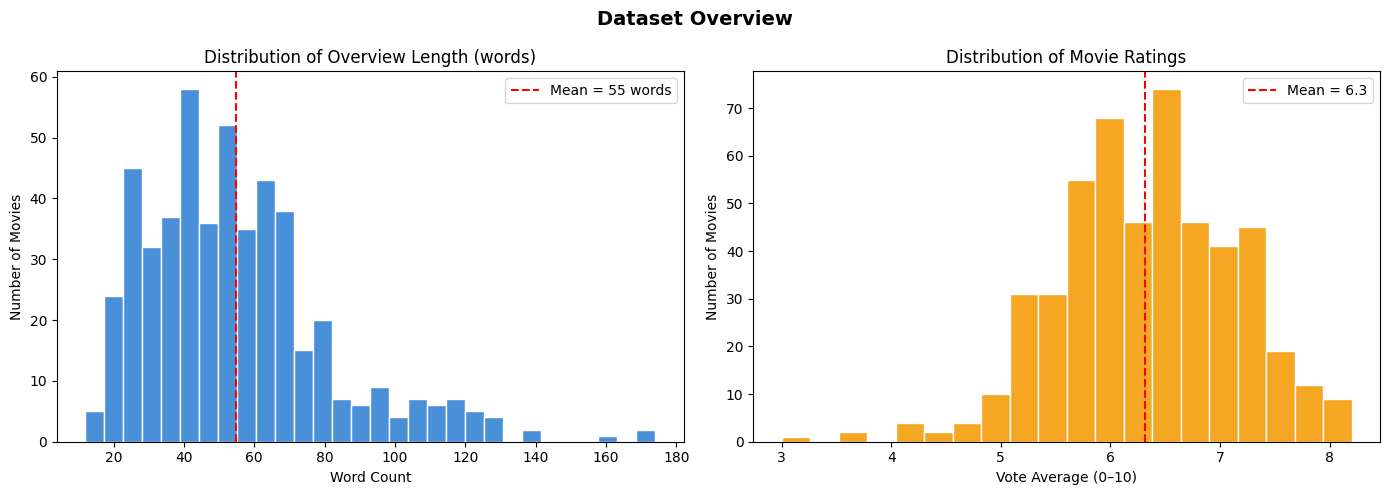


📈 Overview length stats:
count    500.0
mean      54.9
std       26.4
min       12.0
25%       36.0
50%       51.5
75%       67.0
max      174.0
Name: overview_len, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

# ── Overview length distribution ─────────────────────────────────────────────
df["overview_len"] = df["overview"].apply(lambda x: len(x.split()))
axes[0].hist(df["overview_len"], bins=30, color="#4A90D9", edgecolor="white")
axes[0].set_title("Distribution of Overview Length (words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Movies")
axes[0].axvline(df["overview_len"].mean(), color="red", linestyle="--",
                label=f"Mean = {df['overview_len'].mean():.0f} words")
axes[0].legend()

# ── Rating distribution ────────────────────────────────────────────────────────
if "vote_average" in df.columns:
    axes[1].hist(df["vote_average"].dropna(), bins=20, color="#F5A623", edgecolor="white")
    axes[1].set_title("Distribution of Movie Ratings")
    axes[1].set_xlabel("Vote Average (0–10)")
    axes[1].set_ylabel("Number of Movies")
    axes[1].axvline(df["vote_average"].mean(), color="red", linestyle="--",
                    label=f"Mean = {df['vote_average'].mean():.1f}")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "vote_average not available", ha="center", va="center")
    axes[1].set_title("Ratings")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\n📈 Overview length stats:\n{df['overview_len'].describe().round(1)}")


## 🧠 Step 6 — Generate BERT Embeddings

We use **Sentence-BERT** (`sentence-transformers`) which wraps BERT to produce fixed-size sentence vectors.  
Each movie overview → a 384-dimensional vector capturing its **semantic meaning**.


In [7]:
print(f"🔄 Loading BERT model: {MODEL_NAME} ...")
model = SentenceTransformer(MODEL_NAME)
print("✅ Model loaded!")

print(f"\n⚙️  Encoding {len(df)} movie overviews with BERT ...")
print("   (this takes ~30–60 seconds for 500 movies on CPU)")

embeddings = model.encode(
    df["overview"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\n✅ Embeddings generated!")
print(f"   Shape: {embeddings.shape}")
print(f"   Each movie → vector of {embeddings.shape[1]} dimensions")


🔄 Loading BERT model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded!

⚙️  Encoding 500 movie overviews with BERT ...
   (this takes ~30–60 seconds for 500 movies on CPU)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


✅ Embeddings generated!
   Shape: (500, 384)
   Each movie → vector of 384 dimensions


## 📐 Step 7 — Compute Cosine Similarity Matrix

In [8]:
print("🔄 Computing cosine similarity matrix ...")
similarity_matrix = cosine_similarity(embeddings)

print(f"✅ Similarity matrix shape: {similarity_matrix.shape}")
print(f"   Value range: {similarity_matrix.min():.4f} → {similarity_matrix.max():.4f}")
print(f"   Mean off-diagonal similarity: {(similarity_matrix.sum() - len(df)) / (len(df)*(len(df)-1)):.4f}")


🔄 Computing cosine similarity matrix ...
✅ Similarity matrix shape: (500, 500)
   Value range: -0.1911 → 1.0000
   Mean off-diagonal similarity: 0.1663
